In [10]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [11]:
api = wandb.Api()

In [12]:
runs = api.runs(path="harvardml/opt-olmo")

In [13]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',  'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [14]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups = ["momentum-150-tied-1", "momentum-all-1",
          "momentum-150-tied-llama-lite-1", "momentum-llama-lite-2",
          "momentum-300-tied-1", "momentum-300-1",]

group_labels = {
    "150m (standard)": ["momentum-150-tied-1", "momentum-all-1"],
    "150m (no QK norm or z-loss)": ["momentum-150-tied-llama-lite-1", "momentum-llama-lite-2"],
    "300m (standard)": ["momentum-300-tied-1", "momentum-300-1"],
}

for run in runs:
    if run.group in groups:
        history = run.history(samples=25000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
        
        if "300" in run.group:
            step = 50000
        else:
            step = 25000
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["name"] = run.name
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict["learning_rate"] = run.config["optimizer"]["learning_rate"]
        run_dict["beta_0"] = run.config["optimizer"]["beta_0"]
        run_dict["beta_1"] = run.config["optimizer"]["beta_1"]
        run_dict["eps"] = run.config["optimizer"]["eps"]
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [15]:
df

,id,name,group,optimizer,learning_rate,beta_0,beta_1,eps,val_loss,step
0,d6jkzci3,olmo_33522783_30,momentum-300-1,adafactorw,0.003160,0.50,0.95,1.000000e-15,2.909706,50000.0
0,1ou9jiku,olmo_33522783_29,momentum-300-1,adafactorw,0.003160,0.00,0.95,1.000000e-15,2.951850,50000.0
0,ebam6qvp,olmo_33522783_28,momentum-300-1,lionw,0.000316,0.99,0.95,1.000000e-15,2.969591,50000.0
0,7j7gc8j8,olmo_33522783_27,momentum-300-1,lionw,0.000316,0.98,0.95,1.000000e-15,2.946571,50000.0
0,qohxu7jo,olmo_33539319_17,momentum-300-tied-1,novagradw_ours,0.003160,0.80,0.95,1.000000e-15,2.959437,50000.0
...,...,...,...,...,...,...,...,...,...,...
0,6h93lc9b,olmo_26364666_13,momentum-all-1,lionw,0.000316,0.80,0.95,1.000000e-15,3.088297,25000.0
0,02v4uzxk,olmo_26364666_11,momentum-all-1,signsgd,0.000316,0.95,0.95,1.000000e-15,3.072563,25000.0
0,qaju3tdr,olmo_26364666_6,momentum-all-1,sgdw,1.000000,0.90,0.95,1.000000e-15,3.297276,25000.0
0,6lrm4evq,olmo_26364666_5,momentum-all-1,sgdw,1.000000,0.80,0.95,1.000000e-15,3.402063,25000.0


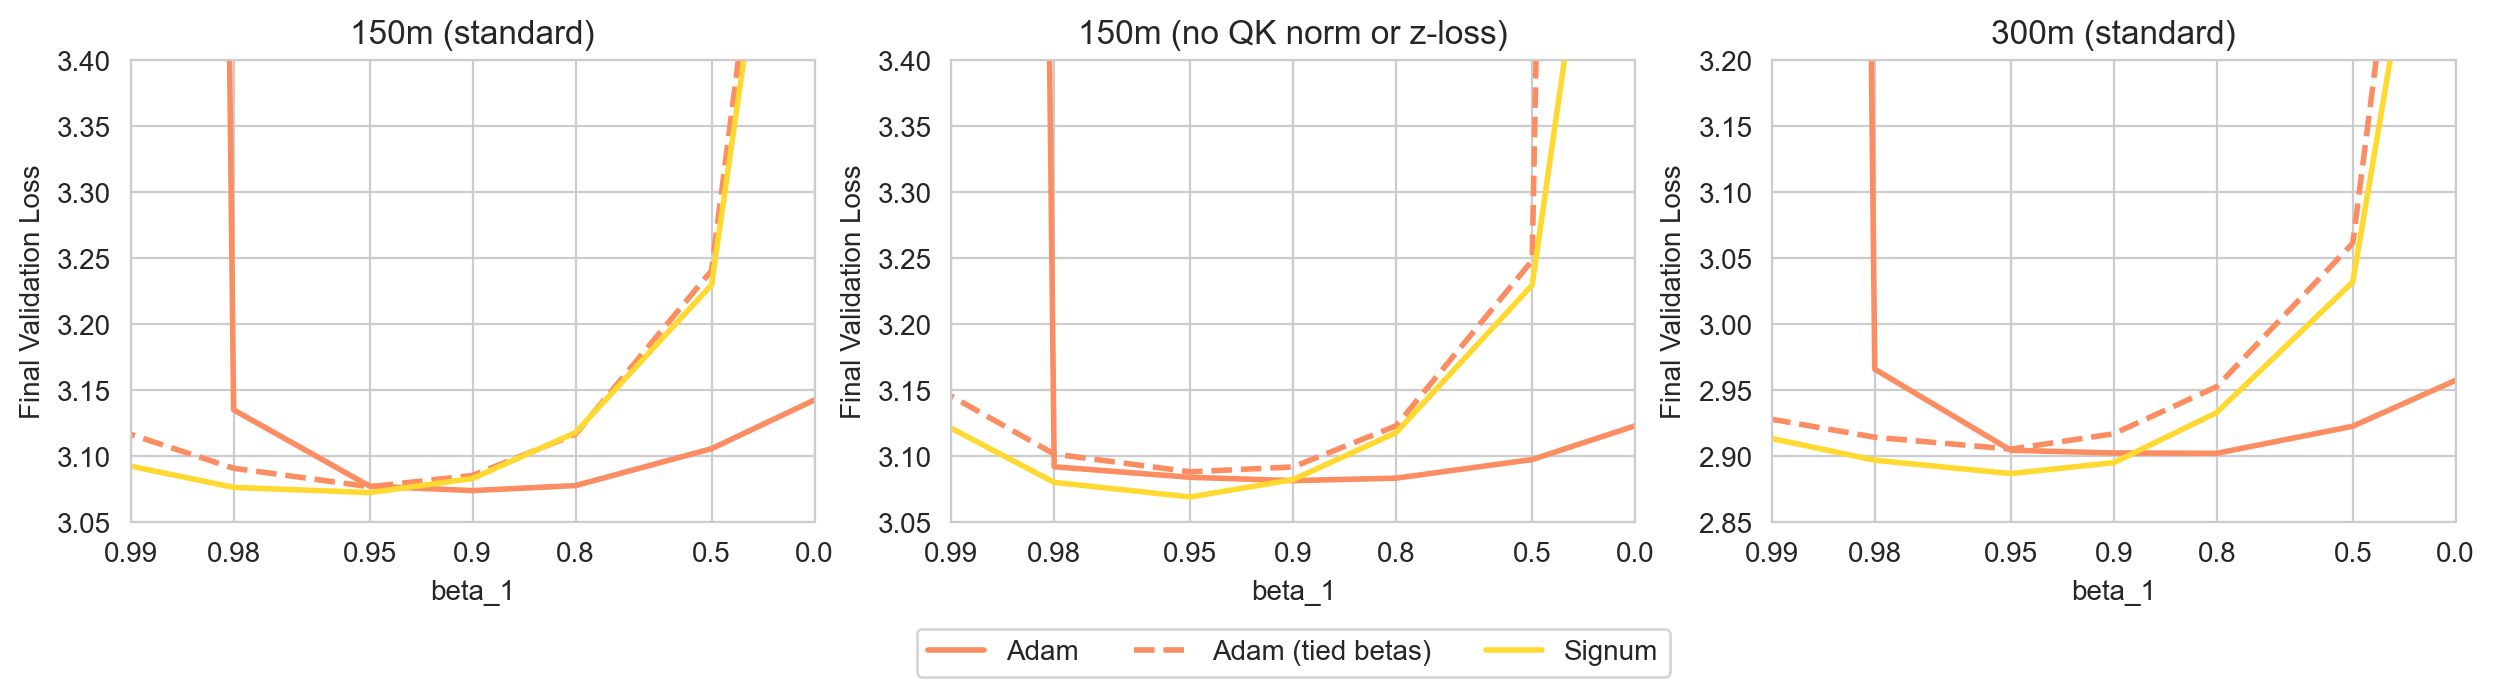

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), dpi=200)

i =0
for g_label, (g1, g2) in group_labels.items():
    ax = axs[i]
    i += 1

    group_df = df

    for optimizer in optimizers:
        if optimizer not in ['adamw', 'signsgd']:
            continue
        if optimizer == "signsgd":
            group_dfs = [df[df["group"] == g2]]
        else:
            group_dfs = [ df[df["group"] == g2], df[df["group"] ==  g1] ]
        
        for group_df in group_dfs:
            if optimizer in group_df["optimizer"].unique():
                optimizer_df = group_df[group_df["optimizer"] == optimizer]
                optimizer_df = optimizer_df.sort_values(by="beta_0")
                optimizer_df = optimizer_df.groupby("beta_0").min().reset_index()
                label = name_map.get(optimizer)
                # if optimizer in ["signsgd"]:
                #     label = "Lion (SignSGD)"
                #     optimizer = 'lionw'
                if g1 in list(group_df["group"]):
                    label = "Adam (tied betas)"
                ax.plot(1 - optimizer_df["beta_0"], 
                        optimizer_df["val_loss"], 
                        label=label,
                        linewidth=2,
                        color=color_map[optimizer],
                        linestyle='--' if label == "Adam (tied betas)" else '-'
                )
                # if optimizer in ["lionw"]:
                #     optimizer_df = df[(df["group"] == "beta-all-1") & (df["optimizer"] == "lionw")]
                #     optimizer_df = optimizer_df.sort_values(by="beta_1")
                #     optimizer_df = optimizer_df.groupby("beta_1").min().reset_index()
                #     label = "Lion (beta 2)"
                #     plt.plot(1 - optimizer_df["beta_1"], 
                #             optimizer_df["val_loss"], 
                #             label=label,
                #             linewidth=2,
                #             color=color_map["lionw"],
                #             linestyle=':',
                #     )


    ax.set_xscale("log")
    if "150m" in g_label:
        ax.set_ylim(3.05, 3.4)
    else:
        ax.set_ylim(2.85, 3.2)
    ax.set_xlim(0.01, 1)

    ax.set_xlabel("beta_1")
    xs = [0.0, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99][::-1]

    xsa = 1 - np.array(xs)
    ax.set_xticks(xsa, xs)
    ax.set_ylabel("Final Validation Loss")
    ax.set_title(g_label)

axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))


plt.savefig('../figures/momentum_tied_all.png', bbox_inches='tight')
plt.show()